## Análisis Exploratorio de Datos (EDA)

El objetivo de esta sección es identificar patrones, tendencias y relaciones entre variables relevantes en la accidentalidad vial, con el fin de apoyar la construcción del modelo predictivo.

In [182]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/raw/VEHICULOS_INV_EN_UN_ACCIDENTE.csv", sep=';' )
df.shape

C:\Users\caror\AppData\Local\Temp\ipykernel_20468\2627299334.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/VEHICULOS_INV_EN_UN_ACCIDENTE.csv", sep=';' )


(406540, 9)

In [183]:
df.columns

Index(['MARCA_VEHICULO', 'MODELO_VEHICULO', 'TIPO_VEHICULO', 'EDAD_VEHICULO',
       'FECHA_ACCIDENTE', 'GRAVEDAD_ACCIDENTE', 'DEPARTAMENTO_ACCIDENTE',
       'MUNICIPIO_ACCIDENTE', 'AUTORIDAD_DE_TRANSITO'],
      dtype='object')

In [184]:
df.head()

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
3,CHEVROLET,2023,CAMIONETA,2.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
4,HONDA,2026,MOTOCICLETA,1.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406540 entries, 0 to 406539
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   MARCA_VEHICULO          406496 non-null  object
 1   MODELO_VEHICULO         406540 non-null  int64 
 2   TIPO_VEHICULO           406540 non-null  object
 3   EDAD_VEHICULO           406520 non-null  object
 4   FECHA_ACCIDENTE         406540 non-null  object
 5   GRAVEDAD_ACCIDENTE      406540 non-null  object
 6   DEPARTAMENTO_ACCIDENTE  406540 non-null  object
 7   MUNICIPIO_ACCIDENTE     406540 non-null  object
 8   AUTORIDAD_DE_TRANSITO   406540 non-null  object
dtypes: int64(1), object(8)
memory usage: 27.9+ MB


In [186]:
df["FECHA_ACCIDENTE"].head()

0    dic-25
1    dic-25
2    dic-25
3    dic-25
4    dic-25
Name: FECHA_ACCIDENTE, dtype: object

In [187]:
df['FECHA_ACCIDENTE'] = df['FECHA_ACCIDENTE'].astype(str).str.lower().str.strip()

In [188]:
df[['MES_STR', 'AÑO_STR']] = df['FECHA_ACCIDENTE'].str.split('-', expand=True)

In [189]:
meses = {
    'ene': 1, 'feb': 2, 'mar': 3, 'abr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'ago': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dic': 12
}

df['MES'] = df['MES_STR'].map(meses)

In [190]:
df['AÑO'] = df['AÑO_STR'].astype(float)
df['AÑO'] = df['AÑO'].apply(lambda x: int(x) + 2000 if x < 100 else int(x))

In [191]:
df['FECHA'] = pd.to_datetime(dict(year=df['AÑO'], month=df['MES'], day=1))

In [192]:
df[['FECHA_ACCIDENTE', 'MES', 'AÑO', 'FECHA']].head()

,FECHA_ACCIDENTE,MES,AÑO,FECHA
0,dic-25,12,2025,2025-12-01
1,dic-25,12,2025,2025-12-01
2,dic-25,12,2025,2025-12-01
3,dic-25,12,2025,2025-12-01
4,dic-25,12,2025,2025-12-01


In [193]:
df = df.dropna(subset=['MES', 'AÑO'])

In [194]:
df.columns = df.columns.str.strip().str.upper()

df['TIPO_VEHICULO'] = df['TIPO_VEHICULO'].str.upper().str.strip()
df['DEPARTAMENTO_ACCIDENTE'] = df['DEPARTAMENTO_ACCIDENTE'].str.upper().str.strip()
df['MUNICIPIO_ACCIDENTE'] = df['MUNICIPIO_ACCIDENTE'].str.upper().str.strip()

In [195]:
df.isnull().sum()

MARCA_VEHICULO            44
MODELO_VEHICULO            0
TIPO_VEHICULO              0
EDAD_VEHICULO             20
FECHA_ACCIDENTE            0
GRAVEDAD_ACCIDENTE         0
DEPARTAMENTO_ACCIDENTE     0
MUNICIPIO_ACCIDENTE        0
AUTORIDAD_DE_TRANSITO      0
MES_STR                    0
AÑO_STR                    0
MES                        0
AÑO                        0
FECHA                      0
dtype: int64

In [196]:
df = df.dropna(subset=['EDAD_VEHICULO', 'MARCA_VEHICULO'])

In [197]:
df['AÑO'] = df['FECHA'].dt.year
df['MES'] = df['FECHA'].dt.month


df['SEVERIDAD'] = df['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: 1 if 'MUERTO' in str(x).upper() else 0
)

In [198]:
df[['FECHA_ACCIDENTE', 'FECHA', 'AÑO', 'MES', 'SEVERIDAD']].head()

df['SEVERIDAD'].value_counts(normalize=True)

SEVERIDAD
0    0.949207
1    0.050793
Name: proportion, dtype: float64

In [199]:
import unicodedata

def limpiar_texto(texto):
    if isinstance(texto, str):
        texto = texto.upper().strip()
        texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
        return texto
    return texto

columnas_texto = [
    "TIPO_VEHICULO",
    "DEPARTAMENTO_ACCIDENTE",
    "MUNICIPIO_ACCIDENTE",
    "MARCA_VEHICULO"
]

for col in columnas_texto:
    df[col] = df[col].apply(limpiar_texto)

In [200]:
df.dtypes

MARCA_VEHICULO                    object
MODELO_VEHICULO                    int64
TIPO_VEHICULO                     object
EDAD_VEHICULO                     object
FECHA_ACCIDENTE                   object
GRAVEDAD_ACCIDENTE                object
DEPARTAMENTO_ACCIDENTE            object
MUNICIPIO_ACCIDENTE               object
AUTORIDAD_DE_TRANSITO             object
MES_STR                           object
AÑO_STR                           object
MES                                int32
AÑO                                int32
FECHA                     datetime64[ns]
SEVERIDAD                          int64
dtype: object

In [201]:
df['EDAD_VEHICULO'] = pd.to_numeric(df['EDAD_VEHICULO'], errors='coerce')

In [202]:
df['EDAD_VEHICULO'].isnull().sum()

np.int64(1)

In [203]:

df['EDAD_VEHICULO'] = pd.to_numeric(df['EDAD_VEHICULO'], errors='coerce')


df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')


df['FECHA_ACCIDENTE'] = pd.to_datetime(df['FECHA_ACCIDENTE'], errors='coerce')

C:\Users\caror\AppData\Local\Temp\ipykernel_20468\1183335485.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['FECHA_ACCIDENTE'] = pd.to_datetime(df['FECHA_ACCIDENTE'], errors='coerce')


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406476 entries, 0 to 406539
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   MARCA_VEHICULO          406476 non-null  object        
 1   MODELO_VEHICULO         406476 non-null  int64         
 2   TIPO_VEHICULO           406476 non-null  object        
 3   EDAD_VEHICULO           406475 non-null  float64       
 4   FECHA_ACCIDENTE         0 non-null       datetime64[ns]
 5   GRAVEDAD_ACCIDENTE      406476 non-null  object        
 6   DEPARTAMENTO_ACCIDENTE  406476 non-null  object        
 7   MUNICIPIO_ACCIDENTE     406476 non-null  object        
 8   AUTORIDAD_DE_TRANSITO   406476 non-null  object        
 9   MES_STR                 406476 non-null  object        
 10  AÑO_STR                 406476 non-null  object        
 11  MES                     406476 non-null  int32         
 12  AÑO                     406476 non-

In [205]:
df['TIPO_VEHICULO'].value_counts().head(10)

TIPO_VEHICULO
MOTOCICLETA     229199
AUTOMOVIL        92162
CAMIONETA        34267
BUS              16127
CAMION           10840
CAMPERO           8590
TRACTOCAMION      5059
MICROBUS          4325
BUSETA            2845
VOLQUETA          1971
Name: count, dtype: int64

In [206]:
import os

os.makedirs("../data/external", exist_ok=True)
os.makedirs("../outputs/images", exist_ok=True)

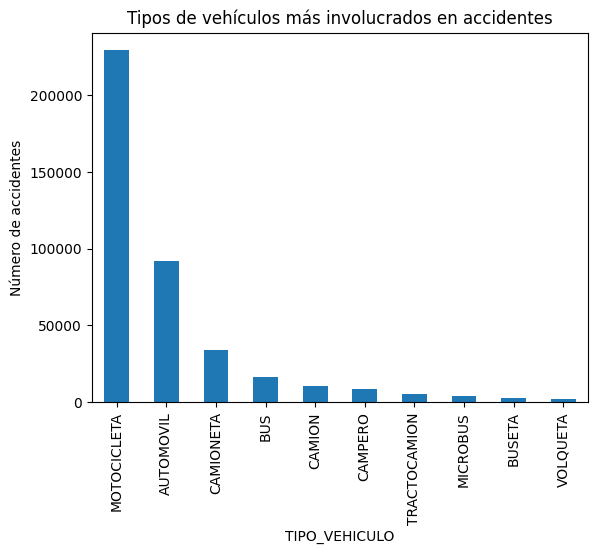

In [207]:
import matplotlib.pyplot as plt

Vehiculos_inv_Accidentes= df['TIPO_VEHICULO'].value_counts().head(10).plot(kind='bar')
plt.title("Tipos de vehículos más involucrados en accidentes")
plt.ylabel("Número de accidentes")
plt.show()

### Insight

Los resultados evidencian que ciertos tipos de vehículos, particularmente las motocicletas, presentan una mayor participación en los accidentes de tránsito.

Este hallazgo coincide con estudios previos en seguridad vial, donde este tipo de vehículo está asociado a mayor vulnerabilidad y riesgo.

In [ ]:
top_departamentos = df['DEPARTAMENTO_ACCIDENTE'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10,5))

top_departamentos.plot(kind='bar', ax=ax)

ax.set_title("Departamentos con mayor número de accidentes")
ax.set_ylabel("Cantidad de accidentes")

for i, v in enumerate(top_departamentos):
    ax.text(i, v + 50, str(v), ha='center')

fig.savefig("../assets/top_departamentos.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

Los departamentos con mayor número de accidentes concentran una proporción importante de la siniestralidad nacional, lo que los convierte en focos clave de análisis y modelado predictivo.

In [ ]:
df_antioquia = df[df['DEPARTAMENTO_ACCIDENTE'] == 'ANTIOQUIA']

In [ ]:
df_antioquia.shape

(161999, 15)

In [ ]:
vehiculos_antioquia = df_antioquia['TIPO_VEHICULO'].value_counts().head(10)

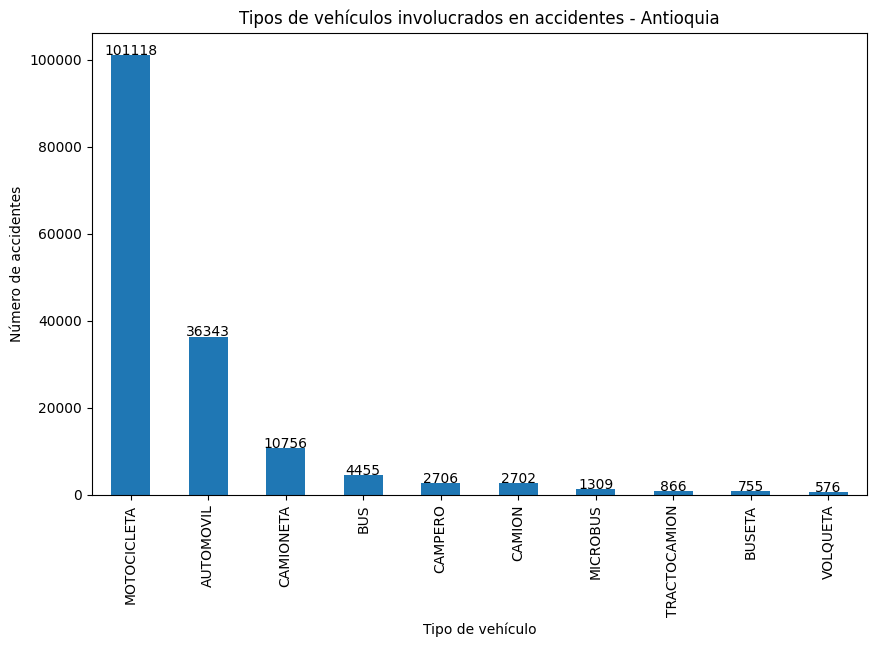

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

vehiculos_antioquia.plot(kind='bar', ax=ax)

ax.set_title("Tipos de vehículos involucrados en accidentes - Antioquia")
ax.set_xlabel("Tipo de vehículo")
ax.set_ylabel("Número de accidentes")

for i, v in enumerate(vehiculos_antioquia):
    ax.text(i, v + 50, str(v), ha='center')

fig.savefig("../assets/vehiculos_antioquia.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

Los resultados evidencian que ciertos tipos de vehículos en el Departamento de Antioquia, las motocicletas siguen liderando, presentan una mayor participación en los accidentes de tránsito.

Estos resultados coinciden con estudios previos en seguridad vial, donde este tipo de vehículo está asociado a mayor vulnerabilidad y riesgo.

In [ ]:
gravedad_antioquia = df_antioquia['GRAVEDAD_ACCIDENTE'].value_counts()

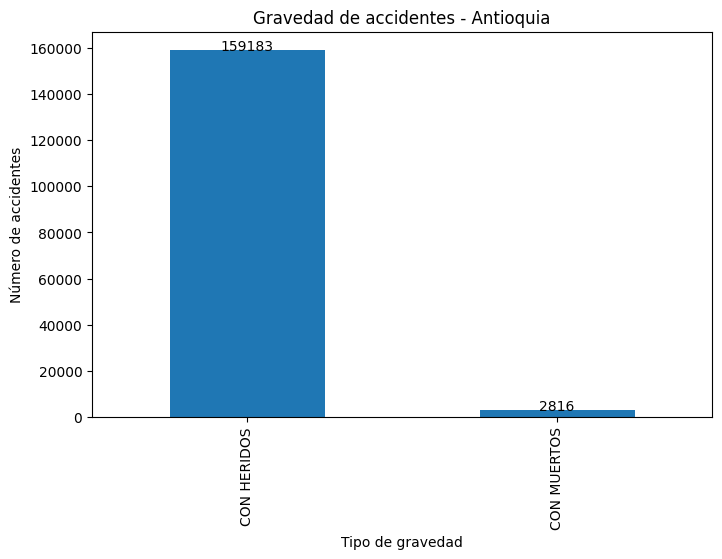

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

gravedad_antioquia.plot(kind='bar', ax=ax)

ax.set_title("Gravedad de accidentes - Antioquia")
ax.set_xlabel("Tipo de gravedad")
ax.set_ylabel("Número de accidentes")

for i, v in enumerate(gravedad_antioquia):
    ax.text(i, v + 50, str(v), ha='center')

fig.savefig("../assets/gravedad_antioquia.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

El análisis específico para el departamento de Antioquia permite identificar patrones locales en la gravedad de accidentes, facilitando un enfoque más detallado a nivel municipal, el cual es fundamental para la toma de decisiones territoriales.

In [ ]:
top_departamentos = df['DEPARTAMENTO_ACCIDENTE'].value_counts().head(10)

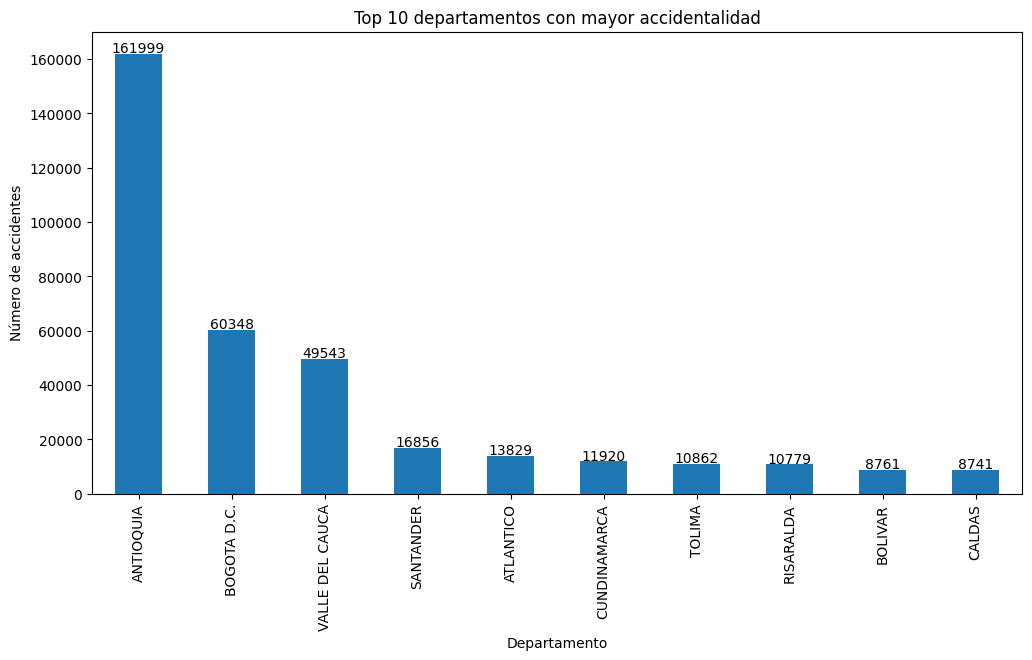

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

top_departamentos.plot(kind='bar', ax=ax)

ax.set_title("Top 10 departamentos con mayor accidentalidad")
ax.set_xlabel("Departamento")
ax.set_ylabel("Número de accidentes")

for i, v in enumerate(top_departamentos):
    ax.text(i, v + 500, str(v), ha='center')

fig.savefig("../assets/top10_departamentos.png", dpi=300, bbox_inches='tight')
plt.show()

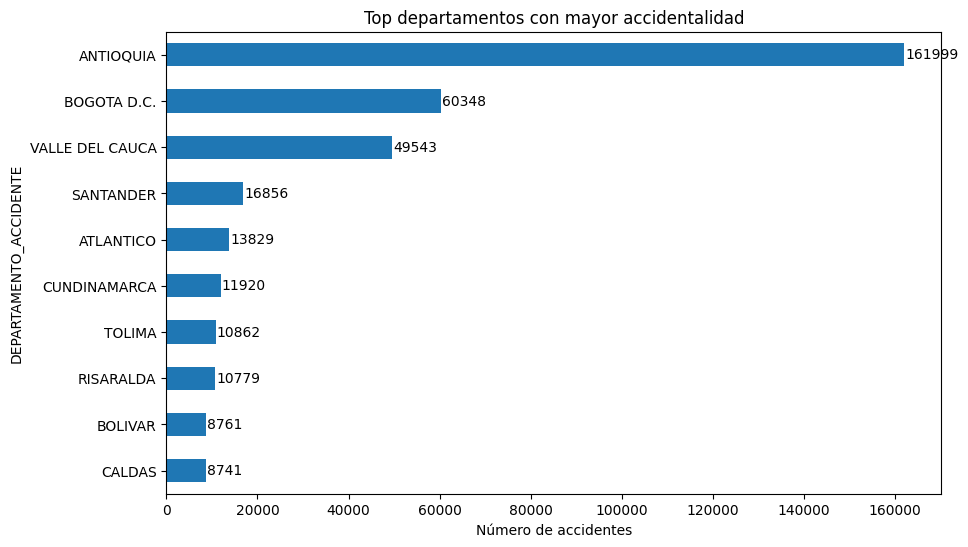

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

top_departamentos.sort_values().plot(kind='barh', ax=ax)

ax.set_title("Top departamentos con mayor accidentalidad")
ax.set_xlabel("Número de accidentes")

for i, v in enumerate(top_departamentos.sort_values()):
    ax.text(v + 200, i, str(v), va='center')

fig.savefig("../assets/top_departamentos_barh.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df['SEVERIDAD'] = df['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: 1 if x == 'CON MUERTOS' else 0
)

In [ ]:
df['SEVERIDAD'].value_counts()

SEVERIDAD
0    385830
1     20646
Name: count, dtype: int64

In [ ]:
y = df['SEVERIDAD']

In [ ]:
X = df[['TIPO_VEHICULO',
        'EDAD_VEHICULO',
        'MODELO_VEHICULO',
        'DEPARTAMENTO_ACCIDENTE']]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X.head()

,EDAD_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO_BUS,TIPO_VEHICULO_BUSETA,TIPO_VEHICULO_CAMION,TIPO_VEHICULO_CAMIONETA,TIPO_VEHICULO_CAMPERO,TIPO_VEHICULO_CICLOMOTOR,TIPO_VEHICULO_CUADRICICLO,TIPO_VEHICULO_CUATRIMOTO,...,DEPARTAMENTO_ACCIDENTE_NARINO,DEPARTAMENTO_ACCIDENTE_NORTE DE SANTANDER,DEPARTAMENTO_ACCIDENTE_PUTUMAYO,DEPARTAMENTO_ACCIDENTE_QUINDIO,DEPARTAMENTO_ACCIDENTE_RISARALDA,DEPARTAMENTO_ACCIDENTE_SANTANDER,DEPARTAMENTO_ACCIDENTE_SUCRE,DEPARTAMENTO_ACCIDENTE_TOLIMA,DEPARTAMENTO_ACCIDENTE_VALLE DEL CAUCA,DEPARTAMENTO_ACCIDENTE_VICHADA
0,9.0,2017,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,20.0,2007,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,9.0,2017,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,2.0,2023,False,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1.0,2026,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
X.isnull().sum()

EDAD_VEHICULO                                                     1
MODELO_VEHICULO                                                   0
TIPO_VEHICULO_BUS                                                 0
TIPO_VEHICULO_BUSETA                                              0
TIPO_VEHICULO_CAMION                                              0
TIPO_VEHICULO_CAMIONETA                                           0
TIPO_VEHICULO_CAMPERO                                             0
TIPO_VEHICULO_CICLOMOTOR                                          0
TIPO_VEHICULO_CUADRICICLO                                         0
TIPO_VEHICULO_CUATRIMOTO                                          0
TIPO_VEHICULO_MAQ. AGRICOLA                                       0
TIPO_VEHICULO_MAQ. INDUSTRIAL                                     0
TIPO_VEHICULO_MICROBUS                                            0
TIPO_VEHICULO_MOTOCARRO                                           0
TIPO_VEHICULO_MOTOCICLETA                       

In [ ]:
X['EDAD_VEHICULO'] = X['EDAD_VEHICULO'].fillna(X['EDAD_VEHICULO'].median())

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X, y)

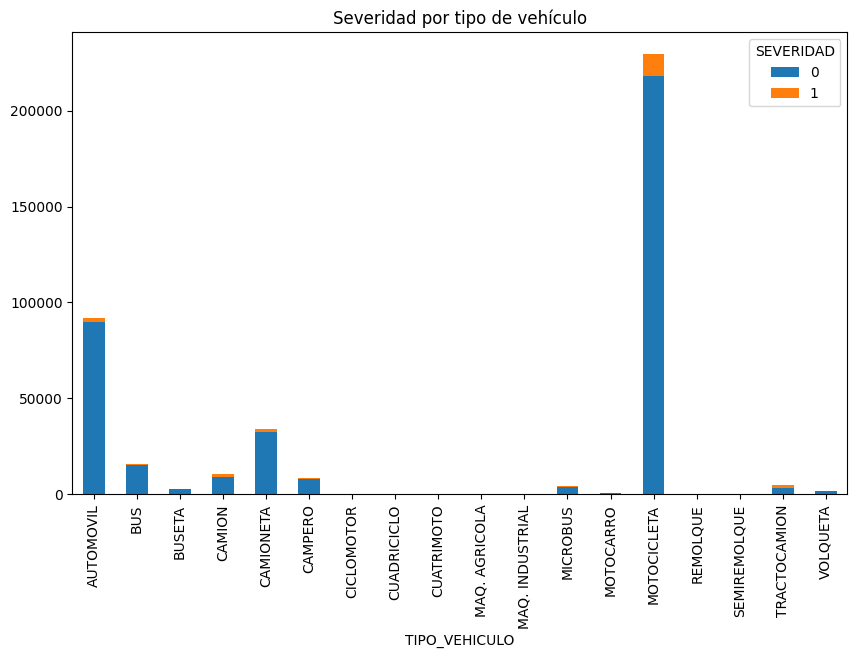

In [ ]:
tabla = pd.crosstab(df['TIPO_VEHICULO'], df['SEVERIDAD'])

tabla.to_csv("../data/external/severidad_por_vehiculo.csv")

fig, ax = plt.subplots(figsize=(10,6))

tabla.plot(kind='bar', stacked=True, ax=ax)

ax.set_title("Severidad por tipo de vehículo")

fig.savefig("../assets/severidad_vehiculo.png", dpi=300, bbox_inches='tight')
plt.show()

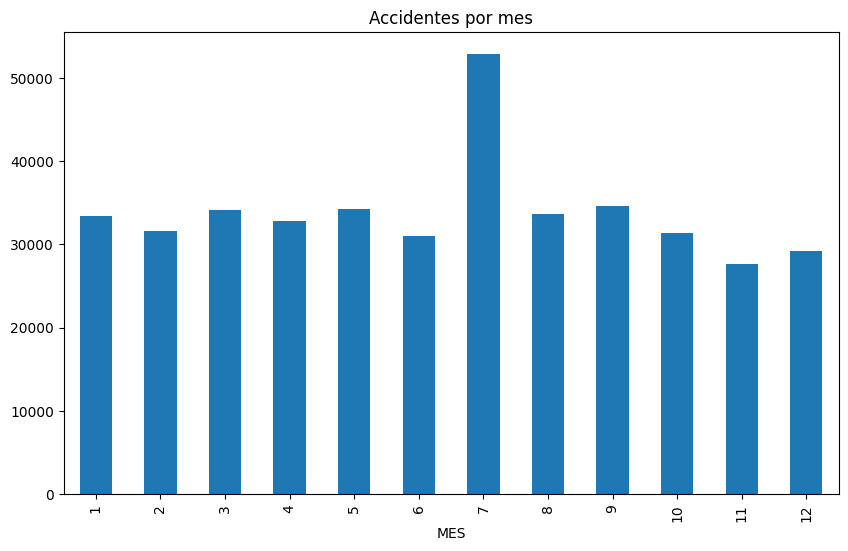

In [ ]:
accidentes_mes = df['MES'].value_counts().sort_index()

accidentes_mes.to_csv("../data/external/accidentes_por_mes.csv")

fig, ax = plt.subplots(figsize=(10,6))

accidentes_mes.plot(kind='bar', ax=ax)

ax.set_title("Accidentes por mes")

fig.savefig("../assets/accidentes_por_mes.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

Se observa una variación en la frecuencia de accidentes a lo largo del año, lo que sugiere la existencia de patrones temporales asociados a factores como condiciones climáticas, movilidad estacional o festividades.

Este comportamiento es relevante para el modelo, ya que la variable temporal (mes) puede influir en la probabilidad de ocurrencia y severidad de los accidentes.

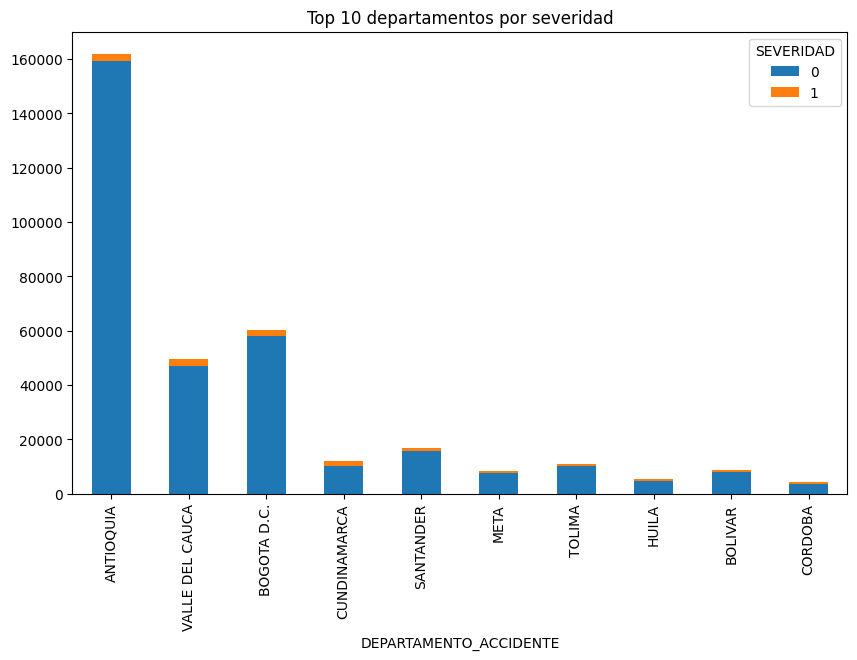

In [ ]:
tabla_dpto = pd.crosstab(df['DEPARTAMENTO_ACCIDENTE'], df['SEVERIDAD'])

tabla_dpto.to_csv("../data/external/severidad_por_departamento.csv")

fig, ax = plt.subplots(figsize=(10,6))

tabla_dpto.sort_values(by=1, ascending=False).head(10).plot(kind='bar', stacked=True, ax=ax)

ax.set_title("Top 10 departamentos por severidad")

fig.savefig("../assets/severidad_departamento.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
kpis = {
    "Total accidentes": len(df),
    "Accidentes severos": int(df['SEVERIDAD'].sum()),
    "Tasa de severidad": round(df['SEVERIDAD'].mean(), 2),
    "Vehículo más frecuente": df['TIPO_VEHICULO'].mode()[0],
    "Departamento más crítico": df['DEPARTAMENTO_ACCIDENTE'].mode()[0]
}

<Axes: xlabel='TIPO_VEHICULO'>

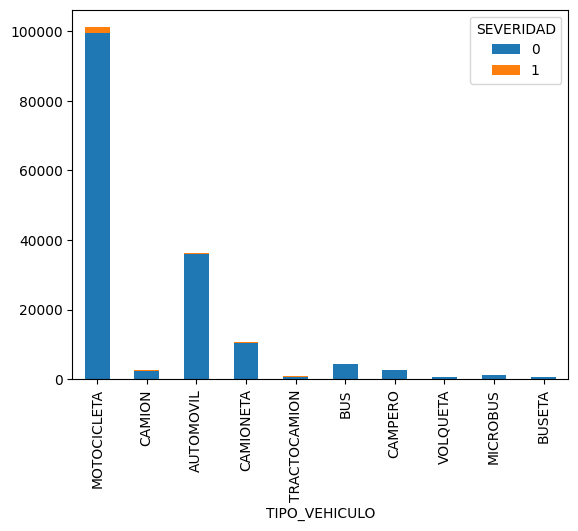

In [ ]:
df_antioquia = df[df['DEPARTAMENTO_ACCIDENTE'] == 'ANTIOQUIA']

pd.crosstab(df_antioquia['TIPO_VEHICULO'], df_antioquia['SEVERIDAD']) \
    .sort_values(by=1, ascending=False) \
    .head(10) \
    .plot(kind='bar', stacked=True)

In [ ]:
df['SEVERIDAD'].value_counts()

SEVERIDAD
0    385830
1     20646
Name: count, dtype: int64

In [ ]:
df_antioquia = df[df["DEPARTAMENTO_ACCIDENTE"] == "ANTIOQUIA"]

In [ ]:
top_municipios = df_antioquia["MUNICIPIO_ACCIDENTE"].value_counts().head(15).index

df_antioquia["MUNICIPIO_GROUP"] = df_antioquia["MUNICIPIO_ACCIDENTE"].apply(
    lambda x: x if x in top_municipios else "OTROS"
)

C:\Users\caror\AppData\Local\Temp\ipykernel_20468\1298631090.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_antioquia["MUNICIPIO_GROUP"] = df_antioquia["MUNICIPIO_ACCIDENTE"].apply(


In [ ]:
from sklearn.utils import resample

df_majority = df_antioquia[df_antioquia["SEVERIDAD"] == 0]
df_minority = df_antioquia[df_antioquia["SEVERIDAD"] == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [ ]:
def clasificar_edad(x):
    if x <= 5:
        return "NUEVO"
    elif x <= 15:
        return "MEDIO"
    else:
        return "ANTIGUO"

df_balanced["EDAD_CAT"] = df_balanced["EDAD_VEHICULO"].apply(clasificar_edad)

In [ ]:
features = [
    "TIPO_VEHICULO",
    "EDAD_CAT",
    "MES",
    "MUNICIPIO_GROUP"
]

In [ ]:
df_model = pd.get_dummies(df_balanced[features], drop_first=True)

y = df_balanced["SEVERIDAD"]

In [ ]:
df.to_csv("../data/processed/dataset_limpio.csv", index=False)

In [ ]:
df_antioquia.to_csv("../data/processed/dataset_antioquia.csv", index=False)

In [ ]:
df_model.to_csv("../data/processed/dataset_modelo.csv", index=False)

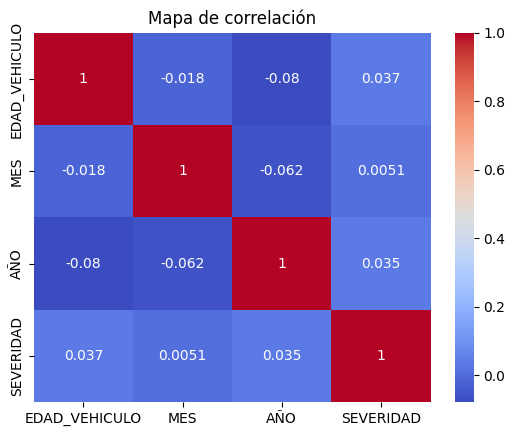

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['EDAD_VEHICULO','MES','AÑO','SEVERIDAD']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Mapa de correlación")

plt.savefig("../assets/correlacion.png", dpi=300, bbox_inches='tight')
plt.show()

### Insight

El análisis de correlación muestra relaciones débiles entre las variables numéricas y la severidad, lo que sugiere la necesidad de modelos no lineales para capturar patrones complejos, justificando el uso de algoritmos como Random Forest.

In [ ]:
df['SEVERIDAD'].value_counts(normalize=True)

SEVERIDAD
0    0.949207
1    0.050793
Name: proportion, dtype: float64

### Insight

Se evidencia un desbalance significativo en la variable objetivo, donde los accidentes no fatales predominan ampliamente.

Este comportamiento justifica la aplicación de técnicas como SMOTE para equilibrar las clases durante el entrenamiento del modelo.

## Conclusiones del EDA

- Se identificaron patrones temporales en la accidentalidad.
- Los tipos de vehículos influyen significativamente en la ocurrencia de accidentes.
- Existen diferencias regionales importantes en la severidad.
- La variable objetivo presenta desbalance, lo que requiere técnicas de balanceo.
- Se justifica el uso de modelos de Machine Learning para capturar relaciones complejas.

Este análisis proporciona la base para la fase de modelado predictivo.